# Raw data exploration

## Team win rates

Everything below comes from `data/raw/scores/2010-2026_scores.csv`, one row per
game. Text tables only for now; the ones worth a chart get plotted later.

Five questions, one section each:

1. win % of each franchise
2. win % at home and on the road
3. how often each franchise reached the playoffs
4. win % once in the playoffs
5. the four answers side by side

**Ground rules**, applied once in the setup cell and valid for every table:

| Decision | Why |
| --- | --- |
| preseason and Pro Bowl are out | not competitive games; `load_scores` drops them by default |
| postseason is **in** for the win-rate tables | a playoff game is still a game the franchise won or lost |
| a tie counts as **half a win** | NFL convention, `(W + 0.5*T) / G`; ties are rare but real |
| relocated franchises are merged | `STL`->`LAR`, `SD`->`LAC`, `OAK`->`LV`, `JAC`->`JAX`, `AZ`->`ARI` -- the question is about the franchise, not the city |
| playoff tables stop at the last finished season | 2026 is partial (`TBD` games), so it would drag every rate down |

In [1]:
import pandas as pd

from nfl_trees.data import POSTSEASON_WEEKS, load_scores
from nfl_trees.paths import SCORES_FILE

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 60)

# Relocated franchises appear under two abbreviations in the file.
FRANCHISE_ALIASES = {"AZ": "ARI", "JAC": "JAX", "STL": "LAR", "SD": "LAC", "OAK": "LV"}


def canonical(team: pd.Series) -> pd.Series:
    """One abbreviation per franchise, across the whole period."""
    return team.astype("string").str.strip().replace(FRANCHISE_ALIASES)


games = load_scores(include_preseason=False, include_postseason=True)
games["HomeTeam"] = canonical(games["HomeTeam"])
games["AwayTeam"] = canonical(games["AwayTeam"])
games["HomeScore"] = pd.to_numeric(games["HomeScore"], errors="coerce")
games["AwayScore"] = pd.to_numeric(games["AwayScore"], errors="coerce")
games["is_post"] = games["Week"].str.upper().str.strip().isin(POSTSEASON_WEEKS)
games = games.dropna(subset=["HomeScore", "AwayScore", "HomeTeam", "AwayTeam"])

print(f"games      : {len(games):>5}")
print(f"seasons    : {games.Season.min()}-{games.Season.max()}")
print(f"franchises : {len(set(games.HomeTeam) | set(games.AwayTeam)):>5}")
print(games.is_post.value_counts().rename({False: "regular season", True: "postseason"}).to_string())

games      :  4363
seasons    : 2010-2025
franchises :    32
is_post
regular season    4175
postseason         188


### The working table: one row per team per game

`scores` is one row per **game**, with the two teams in different columns. Every
question below is about a **team**, so the game table gets stacked: each game
becomes two rows, one from each team's point of view, carrying whether that team
was home or away. This is the shape the rest of the notebook groups by.

In [2]:
def _side(df: pd.DataFrame, team_col: str, own: str, opp: str, venue: str) -> pd.DataFrame:
    out = df[["Season", "Week", "is_post"]].copy()
    out["team"] = df[team_col]
    out["points"] = df[own]
    out["points_against"] = df[opp]
    out["venue"] = venue
    return out


team_games = pd.concat(
    [
        _side(games, "HomeTeam", "HomeScore", "AwayScore", "home"),
        _side(games, "AwayTeam", "AwayScore", "HomeScore", "away"),
    ],
    ignore_index=True,
)
team_games["W"] = (team_games.points > team_games.points_against).astype(int)
team_games["L"] = (team_games.points < team_games.points_against).astype(int)
team_games["T"] = (team_games.points == team_games.points_against).astype(int)
team_games["credit"] = team_games.W + 0.5 * team_games["T"]  # NFL convention


def win_rate(df: pd.DataFrame, label: str = "win%") -> pd.DataFrame:
    """W-L-T and win % per team, over whatever subset is passed in."""
    out = df.groupby("team").agg(
        G=("W", "size"), W=("W", "sum"), L=("L", "sum"), T=("T", "sum"), _c=("credit", "sum")
    )
    out[label] = (100 * out._c / out.G).round(1)
    return out.drop(columns="_c")


print(f"team-game rows: {len(team_games)}  (= 2 x {len(games)} games)")
team_games.head()

team-game rows: 8726  (= 2 x 4363 games)


,Season,Week,is_post,team,points,points_against,venue,W,L,T,credit
0,2010,WEEK 1,False,NO,14.0,9.0,home,1,0,0,1.0
1,2010,WEEK 1,False,TB,17.0,14.0,home,1,0,0,1.0
2,2010,WEEK 1,False,BUF,10.0,15.0,home,0,1,0,0.0
3,2010,WEEK 1,False,NE,38.0,24.0,home,1,0,0,1.0
4,2010,WEEK 1,False,HOU,34.0,24.0,home,1,0,0,1.0


### 1. Win % of each franchise

Regular season and playoffs together, 2010 onwards.

In [3]:
overall = win_rate(team_games, "win%").sort_values("win%", ascending=False)

print("=" * 46)
print("WIN % BY FRANCHISE  (regular season + playoffs)")
print("=" * 46)
print(overall.to_string())
print("-" * 46)
print(f"league total: {overall.G.sum()} team-games, {overall.W.sum()} wins, {overall['T'].sum()} ties")
print(
    f"spread      : {overall['win%'].max():.1f}% ({overall.index[0]}) "
    f"down to {overall['win%'].min():.1f}% ({overall.index[-1]})"
)

WIN % BY FRANCHISE  (regular season + playoffs)
        G    W    L  T  win%
team                        
NE    289  191   98  0  66.1
KC    288  186  102  0  64.6
GB    285  177  105  3  62.6
SEA   283  174  108  1  61.7
BAL   280  170  110  0  60.7
PIT   277  167  108  2  60.6
PHI   279  160  118  1  57.5
NO    273  153  120  0  56.0
BUF   276  152  124  0  55.1
SF    283  153  129  1  54.2
DAL   270  145  124  1  53.9
DEN   274  145  129  0  52.9
MIN   269  141  126  2  52.8
LAR   277  142  134  1  51.4
IND   271  135  135  1  50.0
ATL   270  134  136  0  49.6
LAC   268  132  136  0  49.3
CIN   272  132  137  3  49.1
DET   268  127  139  2  47.8
HOU   277  132  144  1  47.8
MIA   264  124  140  0  47.0
TB    271  124  147  0  45.8
CHI   267  118  149  0  44.2
ARI   265  114  149  2  43.4
TEN   268  114  154  0  42.5
CAR   269  113  155  1  42.2
WAS   267  107  158  2  40.4
NYG   268  107  160  1  40.1
LV    263  102  161  0  38.8
NYJ   264   98  166  0  37.1
JAX   267   93  174  0  

### 2. Win % at home and on the road

The same games, split by where they were played. The `gap` column is the size of
each franchise's home-field advantage in percentage points -- and the league-wide
version of that number is the base rate the `home_win` target has to beat.

In [4]:
home = win_rate(team_games[team_games.venue == "home"], "home win%")
away = win_rate(team_games[team_games.venue == "away"], "away win%")

venue = pd.DataFrame(
    {
        "home G": home.G,
        "home win%": home["home win%"],
        "away G": away.G,
        "away win%": away["away win%"],
    }
)
venue["gap"] = (venue["home win%"] - venue["away win%"]).round(1)

print("=" * 52)
print("HOME vs AWAY  (sorted by home-field advantage)")
print("=" * 52)
print(venue.sort_values("gap", ascending=False).to_string())
print("-" * 52)

league_home = 100 * team_games.loc[team_games.venue == "home", "credit"].mean()
print(f"league-wide home win% : {league_home:.1f}%   <- base rate for the `home_win` target")
print(f"median home-field gap : {venue.gap.median():.1f} points")
print(f"franchises with a negative gap: {list(venue.index[venue.gap < 0]) or 'none'}")

HOME vs AWAY  (sorted by home-field advantage)
      home G  home win%  away G  away win%   gap
team                                            
GB       140       74.3     145       51.4  22.9
CLE      131       44.7     133       22.6  22.1
BUF      140       65.7     136       44.1  21.6
MIA      131       56.5     133       37.6  18.9
MIN      133       61.7     136       44.1  17.6
DEN      142       61.3     132       43.9  17.4
IND      134       58.2     137       42.0  16.2
JAX      134       42.5     133       27.1  15.4
BAL      138       68.1     142       53.5  14.6
CAR      135       48.9     134       35.4  13.5
HOU      139       54.3     138       41.3  13.0
PIT      138       67.0     139       54.3  12.7
NYJ      131       43.5     133       30.8  12.7
LV       131       45.0     132       32.6  12.4
SEA      140       67.1     143       56.3  10.8
ARI      131       48.9     134       38.1  10.8
KC       150       69.3     138       59.4   9.9
CIN      135       54.

### 3. Playoff appearances

A franchise "appeared" in a season if it played at least one postseason game, or
if it holds a `Clinched Playoffs` row (the rows for a first-round bye, which have
no opponent and so are not games).

The denominator is the number of **finished** seasons -- those whose Super Bowl is
already `FINAL`. That leaves 2026 out, which has no playoffs in the file yet.

In [5]:
raw = pd.read_csv(SCORES_FILE)
raw = raw[raw.Season.astype(str).str.isdigit()].copy()
raw["Season"] = raw.Season.astype(int)

is_super_bowl = raw.Week.str.upper().str.strip() == "SUPER BOWL"
finished = sorted(raw.loc[is_super_bowl & (raw.GameStatus == "FINAL"), "Season"].unique())

# `Clinched Playoffs` rows: the team sits in AwayTeam, HomeTeam is empty.
byes = raw.loc[raw.GameStatus == "Clinched Playoffs", ["Season", "AwayTeam"]].rename(
    columns={"AwayTeam": "team"}
)
byes["team"] = canonical(byes["team"])

regular = team_games[~team_games.is_post & team_games.Season.isin(finished)]
postseason = team_games[team_games.is_post & team_games.Season.isin(finished)]

seasons_played = regular.groupby("team").Season.nunique()
reached = (
    pd.concat([postseason[["Season", "team"]], byes[byes.Season.isin(finished)]])
    .drop_duplicates()
    .groupby("team")
    .Season.nunique()
    .reindex(seasons_played.index, fill_value=0)
)

playoffs = pd.DataFrame({"seasons": seasons_played, "appearances": reached})
playoffs["appearance%"] = (100 * playoffs.appearances / playoffs.seasons).round(1)

print("=" * 46)
print(f"PLAYOFF APPEARANCES  ({finished[0]}-{finished[-1]}, {len(finished)} finished seasons)")
print("=" * 46)
print(playoffs.sort_values("appearance%", ascending=False).to_string())
print("-" * 46)
print(f"teams in the bracket per season: {playoffs.appearances.sum() / len(finished):.1f}")
print(f"franchises at 50%+ : {(playoffs['appearance%'] >= 50).sum()} of {len(playoffs)}")

PLAYOFF APPEARANCES  (2010-2025, 16 finished seasons)
      seasons  appearances  appearance%
team                                   
GB         16           13         81.2
KC         16           12         75.0
NE         16           12         75.0
SEA        16           11         68.8
PIT        16           11         68.8
PHI        16           10         62.5
BAL        16           10         62.5
HOU        16            9         56.2
BUF        16            8         50.0
SF         16            8         50.0
LAR        16            7         43.8
NO         16            7         43.8
CIN        16            7         43.8
DEN        16            7         43.8
DAL        16            6         37.5
IND        16            6         37.5
MIN        16            6         37.5
TB         16            5         31.2
ATL        16            5         31.2
LAC        16            5         31.2
CAR        16            5         31.2
DET        16            5

### 4. Win % in the playoffs

Postseason games only. A small denominator, so read it next to `G`: three games
at 66.7% is not the same claim as twenty-eight at 67.9%. Super Bowl appearances
and titles are in the last two columns for context.

In [6]:
post_rate = win_rate(postseason, "playoff win%").reindex(seasons_played.index)
post_rate = post_rate.fillna(0).astype({"G": int, "W": int, "L": int, "T": int})

super_bowls = postseason[postseason.Week.str.upper().str.strip() == "SUPER BOWL"]
post_rate["SB"] = super_bowls.groupby("team").size().reindex(post_rate.index, fill_value=0)
post_rate["titles"] = (
    super_bowls[super_bowls.W == 1].groupby("team").size().reindex(post_rate.index, fill_value=0)
)

print("=" * 58)
print("PLAYOFF RECORD  (postseason games only)")
print("=" * 58)
print(post_rate.drop(columns="T").sort_values("playoff win%", ascending=False).to_string())
print("-" * 58)
print(f"no playoff win at all : {list(post_rate.index[post_rate.W == 0]) or 'none'}")
print(f"titles shared by {(post_rate.titles > 0).sum()} franchises over {len(finished)} seasons")

PLAYOFF RECORD  (postseason games only)
       G   W   L  playoff win%  SB  titles
team                                      
NYG    7   5   2          71.4   1       1
NE    28  19   9          67.9   6       3
KC    27  18   9          66.7   5       3
NYJ    3   2   1          66.7   0       0
SF    22  14   8          63.6   3       0
LAR   16  10   6          62.5   2       1
TB    10   6   4          60.0   1       1
SEA   22  13   9          59.1   3       2
PHI   18  10   8          55.6   3       2
DEN   13   7   6          53.8   2       1
BAL   19  10   9          52.6   1       1
BUF   16   8   8          50.0   0       0
GB    24  12  12          50.0   1       1
JAX    6   3   3          50.0   0       0
ATL    9   4   5          44.4   1       0
HOU   16   7   9          43.8   0       0
TEN    7   3   4          42.9   0       0
NO    12   5   7          41.7   0       0
CIN   12   5   7          41.7   1       0
IND   10   4   6          40.0   0       0
CAR    8   3  

### 5. The four answers side by side

One row per franchise, sorted by overall win %. This is the table to come back to
-- and the one most likely to be worth a chart.

In [7]:
summary = pd.DataFrame(
    {
        "G": overall.G,
        "win%": overall["win%"],
        "home%": venue["home win%"],
        "away%": venue["away win%"],
        "gap": venue.gap,
        "playoff%": playoffs["appearance%"],
        "playoff G": post_rate.G,
        "playoff win%": post_rate["playoff win%"],
        "titles": post_rate.titles,
    }
).sort_values("win%", ascending=False)

print("=" * 88)
print("SUMMARY   win% = all games | home%/away% = by venue | playoff% = seasons reached")
print("=" * 88)
print(summary.to_string())
print("-" * 88)
print("correlation between the rates:")
print(summary[["win%", "home%", "away%", "playoff%", "playoff win%"]].corr().round(2).to_string())

SUMMARY   win% = all games | home%/away% = by venue | playoff% = seasons reached
        G  win%  home%  away%   gap  playoff%  playoff G  playoff win%  titles
team                                                                          
NE    289  66.1   69.5   62.3   7.2      75.0         28          67.9       3
KC    288  64.6   69.3   59.4   9.9      75.0         27          66.7       3
GB    285  62.6   74.3   51.4  22.9      81.2         24          50.0       1
SEA   283  61.7   67.1   56.3  10.8      68.8         22          59.1       2
BAL   280  60.7   68.1   53.5  14.6      62.5         19          52.6       1
PIT   277  60.6   67.0   54.3  12.7      68.8         16          31.2       0
PHI   279  57.5   59.8   55.1   4.7      62.5         18          55.6       2
NO    273  56.0   60.6   51.5   9.1      43.8         12          41.7       0
BUF   276  55.1   65.7   44.1  21.6      50.0         16          50.0       0
SF    283  54.2   58.2   50.3   7.9      50.0     

### 6. Divisions: win rate against Super Bowls won

The division is not in the scores file -- `HomeTeam`/`AwayTeam` are the only team
columns -- so the mapping is hard-coded below. It is safe to hard-code for this
period: the eight four-team divisions have been stable since 2002, and the three
franchises that moved city stayed in their division.

One thing to keep in mind while reading it: teams play six of their games
**inside** their own division, and those are zero-sum. That compresses the
division win rate toward 50% (the whole spread is 43.9% to 52.8%), while Super
Bowls are counted out of only 16, so they come in whole units of 0 to 4. The two
measures are on very different scales, which is exactly why they get one axis
each rather than two on the same plot.

In [8]:
DIVISIONS = {
    "BUF": "AFC East", "MIA": "AFC East", "NE": "AFC East", "NYJ": "AFC East",
    "BAL": "AFC North", "CIN": "AFC North", "CLE": "AFC North", "PIT": "AFC North",
    "HOU": "AFC South", "IND": "AFC South", "JAX": "AFC South", "TEN": "AFC South",
    "DEN": "AFC West", "KC": "AFC West", "LAC": "AFC West", "LV": "AFC West",
    "DAL": "NFC East", "NYG": "NFC East", "PHI": "NFC East", "WAS": "NFC East",
    "CHI": "NFC North", "DET": "NFC North", "GB": "NFC North", "MIN": "NFC North",
    "ATL": "NFC South", "CAR": "NFC South", "NO": "NFC South", "TB": "NFC South",
    "ARI": "NFC West", "LAR": "NFC West", "SEA": "NFC West", "SF": "NFC West",
}
assert set(DIVISIONS) == set(overall.index), "division map and franchise list disagree"

team_games["division"] = team_games.team.map(DIVISIONS)
by_div = team_games.groupby("division").agg(G=("W", "size"), W=("W", "sum"), _c=("credit", "sum"))
by_div["win%"] = (100 * by_div._c / by_div.G).round(1)
by_div = by_div.drop(columns="_c")

div_of = post_rate.index.map(DIVISIONS)
by_div["SB"] = post_rate.SB.groupby(div_of).sum()
by_div["titles"] = post_rate.titles.groupby(div_of).sum()
by_div["playoff%"] = playoffs["appearance%"].groupby(playoffs.index.map(DIVISIONS)).mean().round(1)

by_div = by_div.sort_values("win%", ascending=False)

r_titles = by_div["win%"].corr(by_div.titles)
r_appearances = by_div["win%"].corr(by_div.SB)

print("=" * 62)
print("BY DIVISION  (win% = all games 2010-2025 | SB = appearances)")
print("=" * 62)
print(by_div.to_string())
print("-" * 62)
print(f"win% vs titles          : r = {r_titles:.2f}  (Pearson, n=8)")
print(f"win% vs SB appearances  : r = {r_appearances:.2f}")
print(f"win% spread             : {by_div['win%'].min()}% to {by_div['win%'].max()}%"
      f"  ({by_div['win%'].max() - by_div['win%'].min():.1f} points)")

BY DIVISION  (win% = all games 2010-2025 | SB = appearances)
              G    W  win%  SB  titles  playoff%
division                                        
NFC West   1108  583  52.8   8       3      45.3
NFC North  1089  563  52.0   1       1      43.7
AFC East   1093  565  51.7   6       3      37.5
AFC West   1093  565  51.7   7       4      40.6
AFC North  1093  557  51.2   3       1      46.9
NFC South  1083  524  48.4   3       1      34.4
NFC East   1084  519  48.1   4       3      36.0
AFC South  1083  474  43.9   0       0      34.4
--------------------------------------------------------------
win% vs titles          : r = 0.56  (Pearson, n=8)
win% vs SB appearances  : r = 0.65
win% spread             : 43.9% to 52.8%  (8.9 points)


#### The chart

Two panels of the same eight divisions, because the question has two halves.

**Left** is what was asked for: division on x, Super Bowls won on y, with the
divisions **ordered by win rate** (best on the left) and each one's win rate
printed under its name. If the two measures moved together, the columns would
step down from left to right.

**Right** is the correlation itself, where win rate gets a real axis instead of
just a sort order -- the only way to see that six of the eight divisions sit
inside a 4-point band, so the fitted line is resting on very little.

Single series, single hue: the columns are all one blue, since their height
already carries the value. Coloring them light-to-dark by win rate would paint a
9-point spread as if it were the full range of the ramp.

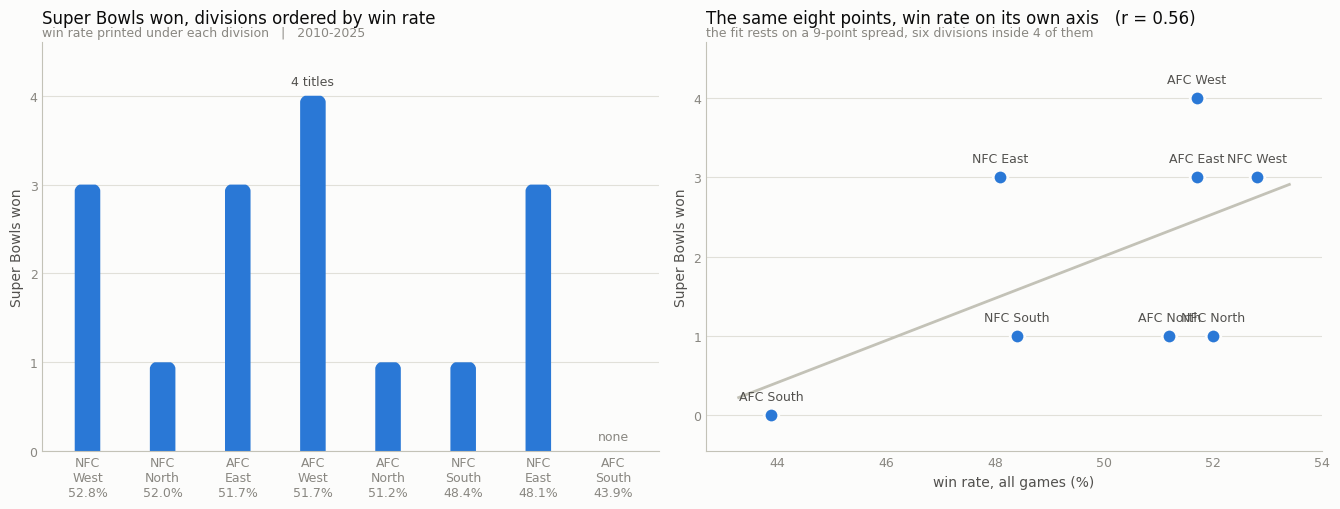

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# Chart tokens: one surface, recessive chrome, one series hue.
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, BLUE = "#e1e0d9", "#c3c2b7", "#2a78d6"


def rounded_column(ax, x, height, width, radius, color):
    """A column with a 4px-ish rounded cap and a square base."""
    r = min(radius, width / 2, height) if height > 0 else 0
    left, right, top = x - width / 2, x + width / 2, height
    k = r * 0.4477  # circle-to-bezier constant
    verts = [
        (left, 0), (left, top - r),
        (left, top - r + k), (left + r - k, top), (left + r, top),
        (right - r, top),
        (right - r + k, top), (right, top - r + k), (right, top - r),
        (right, 0), (left, 0),
    ]
    codes = [
        Path.MOVETO, Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO, Path.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(Path(verts, codes), facecolor=color, edgecolor="none"))


def strip_chrome(ax, *, xgrid=False):
    """Hairline solid grid, no box, muted tick text."""
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
        ax.spines[side].set_linewidth(0.8)
    ax.grid(axis="x" if xgrid else "y", color=GRID, linewidth=0.8, linestyle="-")
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)


fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13.5, 5.2), facecolor=SURFACE)

# ---- left: the divisions on x, Super Bowls on y, ordered by win rate ---------
x = np.arange(len(by_div))
for xi, titles in zip(x, by_div.titles):
    rounded_column(ax_a, xi, titles, 0.34, 0.07, BLUE)

strip_chrome(ax_a)
ax_a.set_xlim(-0.6, len(by_div) - 0.4)
ax_a.set_ylim(0, 4.6)
ax_a.set_yticks(range(5))
ax_a.set_xticks(x)
ax_a.set_xticklabels(
    [f"{d.split()[0]}\n{d.split()[1]}\n{w:.1f}%" for d, w in zip(by_div.index, by_div["win%"])]
)
ax_a.set_ylabel("Super Bowls won", color=INK_2, fontsize=10)
ax_a.set_title(
    "Super Bowls won, divisions ordered by win rate",
    color=INK, fontsize=12, loc="left", pad=14,
)
ax_a.text(
    0, 1.015, "win rate printed under each division   |   2010-2025",
    transform=ax_a.transAxes, color=MUTED, fontsize=9,
)

# Direct-label only the two ends of the story.
top = by_div.titles.idxmax()
ax_a.annotate(
    f"{by_div.titles.max()} titles",
    xy=(list(by_div.index).index(top), by_div.titles.max()),
    xytext=(0, 8), textcoords="offset points",
    ha="center", color=INK_2, fontsize=9,
)
empty = list(by_div.index[by_div.titles == 0])
for name in empty:
    ax_a.annotate(
        "none", xy=(list(by_div.index).index(name), 0), xytext=(0, 8),
        textcoords="offset points", ha="center", color=MUTED, fontsize=9,
    )

# ---- right: the correlation, with win rate on a real axis --------------------
xs, ys = by_div["win%"].to_numpy(), by_div.titles.to_numpy()
slope, intercept = np.polyfit(xs, ys, 1)
line_x = np.array([xs.min() - 0.6, xs.max() + 0.6])
ax_b.plot(line_x, slope * line_x + intercept, color=AXIS, linewidth=2, zorder=1)
ax_b.scatter(xs, ys, s=110, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=3)

for name, xi, yi in zip(by_div.index, xs, ys):
    ax_b.annotate(
        name, xy=(xi, yi), xytext=(0, 11), textcoords="offset points",
        ha="center", color=INK_2, fontsize=9,
    )

strip_chrome(ax_b)
ax_b.set_xlim(xs.min() - 1.2, xs.max() + 1.2)
ax_b.set_ylim(-0.45, 4.7)
ax_b.set_yticks(range(5))
ax_b.set_xlabel("win rate, all games (%)", color=INK_2, fontsize=10)
ax_b.set_ylabel("Super Bowls won", color=INK_2, fontsize=10)
ax_b.set_title(
    f"The same eight points, win rate on its own axis   (r = {r_titles:.2f})",
    color=INK, fontsize=12, loc="left", pad=14,
)
ax_b.text(
    0, 1.015, "the fit rests on a 9-point spread, six divisions inside 4 of them",
    transform=ax_b.transAxes, color=MUTED, fontsize=9,
)

fig.tight_layout()
plt.show()

## Scoring drives: offense, defense, and winning

Everything above came from `scores`. This section is the first use of `plays`,
to ask whether the last sixteen seasons were won by offense or by defense.

The unit is the **drive**, not the play. A per-play rate is arithmetically fine
but unreadable -- the whole league lives between 5% and 7%, and nobody has an
intuition for what one point of that is worth. A drive is the unit the game is
actually managed in: a team gets about eleven or twelve of them per game, and
either comes away with points or does not.

Two rates per franchise:

- **`score%`** -- of the drives this team had, the share that ended in points
- **`allowed%`** -- of its opponents' drives in those same games, the share that
  ended in points

Then each is correlated with the win rate from section 1. The comparison of the
two correlations is the answer: whichever is stronger is what the league rewards.

### Three things about `plays` that decide the numbers

**`DriveNumber` restarts every quarter.** It is not a drive counter for the game.
Grouping by `DriveNumber` alone yields about 7 "drives" per game of 23 plays
each, when a real game has around 23 drives of 6 plays. The key for a drive is
`Season / Week / AwayTeam / HomeTeam / Quarter / DriveNumber`, and
`PlayNumberInDrive` confirms it: it runs 1..n and restarts inside each of those
groups. A drive that runs across a quarter break would be split in two by this,
but the source has already broken possessions at the quarter -- only 11 of the
17,703 quarter-opening drives in the period continue a previous one, so the
effect is nil and no repair is worth the code.

**`TeamWithPossession` is the offense -- except when the defense scores.** On a
normal play it is the team that snapped the ball: on an interception returned but
not scored, the column still names the *passing* team. On a pick-six it flips to
the team that reached the end zone. So the drive's owner is taken from its
**first** play, and a scoring play only counts for that drive when the scorer is
the owner. Without that check, a pick-six would be recorded as a scoring drive
for the offense that threw the interception.

**`IsScoringPlay` means touchdown, field goal, or extra point** -- nothing else.
The extra point is dropped, since it is automatic and already implied by the
touchdown, which leaves touchdowns and field goals. A `Safety` is worth two
points to the defense and is not flagged at all, so a drive that ends in one is
not counted as a scoring drive.

None of the per-play bookkeeping matters here. Timeouts, penalties and kickoff
rows were a problem for a per-play denominator; a drive contains whatever it
contains, and the count of drives is unaffected.

In [10]:
import glob

from nfl_trees.data import filter_weeks
from nfl_trees.paths import PLAYS_DIR

# The plays files are ~177 MB, most of it `PlayDescription`. Read the ten
# columns this section needs and the whole period loads in a few seconds.
PLAY_COLS = [
    "Season", "Week", "AwayTeam", "HomeTeam", "Quarter", "TeamWithPossession",
    "DriveNumber", "PlayNumberInDrive", "IsScoringDrive", "IsScoringPlay", "PlayOutcome",
]

plays = pd.concat(
    [pd.read_csv(f, usecols=PLAY_COLS, low_memory=False)
     for f in sorted(glob.glob(str(PLAYS_DIR / "*_plays.csv")))],
    ignore_index=True,
)
plays = filter_weeks(plays, include_preseason=False, include_postseason=True)
plays = plays[plays.Season.isin(games.Season.unique())].reset_index(drop=True)

# `plays` carries full names, `scores` carries abbreviations. The plays files
# use the *current* name for every season, so this needs no historical entries.
NAME_TO_ABBR = {
    "Arizona Cardinals": "ARI", "Atlanta Falcons": "ATL", "Baltimore Ravens": "BAL",
    "Buffalo Bills": "BUF", "Carolina Panthers": "CAR", "Chicago Bears": "CHI",
    "Cincinnati Bengals": "CIN", "Cleveland Browns": "CLE", "Dallas Cowboys": "DAL",
    "Denver Broncos": "DEN", "Detroit Lions": "DET", "Green Bay Packers": "GB",
    "Houston Texans": "HOU", "Indianapolis Colts": "IND", "Jacksonville Jaguars": "JAX",
    "Kansas City Chiefs": "KC", "Las Vegas Raiders": "LV", "Los Angeles Chargers": "LAC",
    "Los Angeles Rams": "LAR", "Miami Dolphins": "MIA", "Minnesota Vikings": "MIN",
    "New England Patriots": "NE", "New Orleans Saints": "NO", "New York Giants": "NYG",
    "New York Jets": "NYJ", "Philadelphia Eagles": "PHI", "Pittsburgh Steelers": "PIT",
    "San Francisco 49ers": "SF", "Seattle Seahawks": "SEA", "Tampa Bay Buccaneers": "TB",
    "Tennessee Titans": "TEN", "Washington Commanders": "WAS",
}
assert set(plays.TeamWithPossession) == set(NAME_TO_ABBR), "unexpected team name in plays"

GAME_KEY = ["Season", "Week", "AwayTeam", "HomeTeam"]
DRIVE_KEY = GAME_KEY + ["Quarter", "DriveNumber"]  # DriveNumber restarts each quarter
plays["drive_id"] = plays.groupby(DRIVE_KEY).ngroup()

n_games = plays.groupby(GAME_KEY).ngroups
print(f"games                : {n_games:>6}")
print(f"plays                : {len(plays):>6}")
print(f"drives               : {plays.drive_id.nunique():>6}")
print(f"drives per team-game : {plays.drive_id.nunique() / n_games / 2:>6.1f}   NFL reality: ~11.5")

games                :   4360
plays                : 742681
drives               :  98907
drives per team-game :   11.3   NFL reality: ~11.5


### Building the drive table

One row per drive: who had it, and whether it ended in points *for them*. The
owner comes from the drive's first play, and a touchdown or field goal only
counts if the team credited with it is that owner -- which is what keeps a
pick-six from being scored as the intercepted team's own scoring drive.

Two checks run on the result. The share of drives that end in points is compared
against the league's real rate, and the derived flag is compared against the
source's own `IsScoringDrive` column, which is not used for anything else.

In [11]:
by_drive = plays.groupby("drive_id", sort=False)

drives = pd.DataFrame({
    "Season": by_drive.Season.first(),
    "team": by_drive.TeamWithPossession.first().map(NAME_TO_ABBR),
    "home": canonical(by_drive.HomeTeam.first()),
    "away": canonical(by_drive.AwayTeam.first()),
    "plays": by_drive.size(),
    "source_flag": by_drive.IsScoringDrive.max(),
})
drives["opponent"] = drives.home.where(drives.team != drives.home, drives.away)

# A touchdown or field goal counts for the drive only when the team credited
# with it is the drive's own team: on a defensive score, possession flips.
owner = plays.drive_id.map(drives.team)
scored = (
    plays.PlayOutcome.isin(["Touchdown", "Field Goal"])
    & plays.TeamWithPossession.map(NAME_TO_ABBR).eq(owner)
)
drives["scored"] = scored.groupby(plays.drive_id).max().astype(int)

disagree = int((drives.scored != drives.source_flag).sum())
print(f"drives                          : {len(drives):>6}")
print(f"ended in points                 : {100 * drives.scored.mean():>5.1f}%   NFL reality: ~36-38%")
print(f"source `IsScoringDrive` says    : {100 * drives.source_flag.mean():>5.1f}%")
print(f"rows where the two disagree     : {disagree:>6}")
print(f"plays per drive                 : {drives.plays.mean():>6.1f}"
      f"   (penalty and timeout rows included, so above the ~6 real snaps)")
drives.head()

drives                          :  98907
ended in points                 :  37.0%   NFL reality: ~36-38%
source `IsScoringDrive` says    :  37.0%
rows where the two disagree     :    111
plays per drive                 :    7.5   (penalty and timeout rows included, so above the ~6 real snaps)


,Season,team,home,away,plays,source_flag,opponent,scored
drive_id,,,,,,,,
451,2010,NO,NO,MIN,7,1,MIN,1
452,2010,MIN,NO,MIN,5,0,NO,0
453,2010,NO,NO,MIN,4,0,MIN,0
454,2010,MIN,NO,MIN,9,0,NO,0
455,2010,NO,NO,MIN,12,0,MIN,0


### The two rates

The numbers are now on a scale that means something: a good offense turns roughly
two drives in five into points, a bad one closer to three in ten. One percentage
point is about one drive every three games.

In [12]:
offense = drives.groupby("team").scored.agg(drives="size", scored="sum")
offense["score%"] = (100 * offense.scored / offense.drives).round(1)

defense = drives.groupby("opponent").scored.agg(faced="size", allowed="sum")
defense["allowed%"] = (100 * defense.allowed / defense.faced).round(1)

rates = pd.concat([offense, defense], axis=1)
rates["win%"] = overall["win%"]
rates["net"] = (rates["score%"] - rates["allowed%"]).round(1)
rates.index.name = "team"

r_off = rates["score%"].corr(rates["win%"])
r_def = rates["allowed%"].corr(rates["win%"])
r_net = rates["net"].corr(rates["win%"])

cols = ["drives", "score%", "allowed%", "net", "win%"]
print("=" * 50)
print("BEST 8 BY SCORING-DRIVE RATE")
print("=" * 50)
print(rates.sort_values("score%", ascending=False).head(8)[cols].to_string())
print()
print("=" * 50)
print("BEST 8 BY SCORING-DRIVE RATE ALLOWED  (lower is better)")
print("=" * 50)
print(rates.sort_values("allowed%").head(8)[cols].to_string())
print()
print("=" * 50)
print("WORST 6 BY SCORING-DRIVE RATE")
print("=" * 50)
print(rates.sort_values("score%").head(6)[cols].to_string())
print("-" * 50)
print(f"score%   ranges {rates['score%'].min()} to {rates['score%'].max()}")
print(f"allowed% ranges {rates['allowed%'].min()} to {rates['allowed%'].max()}")
print()
print("correlation with win rate, 32 franchises:")
print(f"  offense  r(score%,   win%) = {r_off:+.2f}")
print(f"  defense  r(allowed%, win%) = {r_def:+.2f}")
print(f"  both     r(net,      win%) = {r_net:+.2f}")

BEST 8 BY SCORING-DRIVE RATE
      drives  score%  allowed%  net  win%
team                                     
DAL     2988    42.0      38.5  3.5  53.9
NE      3289    42.0      32.6  9.4  66.1
GB      3104    41.6      37.2  4.4  62.6
KC      3163    41.2      35.1  6.1  64.6
NO      3026    40.9      38.2  2.7  56.0
ATL     2928    40.7      40.3  0.4  49.6
BAL     3218    40.1      33.5  6.6  60.7
LAC     2901    40.0      37.3  2.7  49.3

BEST 8 BY SCORING-DRIVE RATE ALLOWED  (lower is better)
      drives  score%  allowed%  net  win%
team                                     
NE      3289    42.0      32.6  9.4  66.1
BAL     3218    40.1      33.5  6.6  60.7
SEA     3241    38.9      33.9  5.0  61.7
PIT     3157    37.4      34.7  2.7  60.6
SF      3175    38.6      34.9  3.7  54.2
KC      3163    41.2      35.1  6.1  64.6
DEN     3234    35.2      35.2  0.0  52.9
BUF     3138    38.0      35.3  2.7  55.1

WORST 6 BY SCORING-DRIVE RATE
      drives  score%  allowed%  net  win%
t

### Does the answer change over time?

The correlations above are pooled over sixteen seasons, which would hide a shift
inside the period. The question was specifically about *recent* years, so the
same two correlations get recomputed inside each season -- 32 teams per season,
season win rate against season drive rates -- and the two halves compared.

In [13]:
season_off = drives.groupby(["Season", "team"]).scored.agg(["size", "sum"])
season_off = (100 * season_off["sum"] / season_off["size"]).rename("score%")

season_def = drives.groupby(["Season", "opponent"]).scored.agg(["size", "sum"])
season_def = (100 * season_def["sum"] / season_def["size"]).rename("allowed%")
season_def.index.names = ["Season", "team"]

season_win = team_games.groupby(["Season", "team"]).credit.mean().mul(100).rename("win%")
by_season = pd.concat([season_off, season_def, season_win], axis=1).dropna()

trend = pd.DataFrame(
    [
        {
            "Season": season,
            "teams": len(grp),
            "r_offense": round(grp["score%"].corr(grp["win%"]), 2),
            "r_defense": round(grp["allowed%"].corr(grp["win%"]), 2),
        }
        for season, grp in by_season.groupby(level="Season")
    ]
).set_index("Season")
trend["edge"] = (trend.r_offense.abs() - trend.r_defense.abs()).round(2)

print("=" * 46)
print("CORRELATION WITH WIN RATE, SEASON BY SEASON")
print("=" * 46)
print(trend.to_string())
print("-" * 46)
first, second = trend.loc[:2017], trend.loc[2018:]
print(f"2010-2017 mean : offense {first.r_offense.mean():+.2f}   defense {first.r_defense.mean():+.2f}")
print(f"2018-2025 mean : offense {second.r_offense.mean():+.2f}   defense {second.r_defense.mean():+.2f}")
print(f"seasons where defense correlated more strongly: {list(trend.index[trend.edge < 0])}")

CORRELATION WITH WIN RATE, SEASON BY SEASON
        teams  r_offense  r_defense  edge
Season                                   
2010       32       0.69      -0.69  0.00
2011       32       0.74      -0.53  0.21
2012       32       0.78      -0.59  0.19
2013       32       0.74      -0.67  0.07
2014       32       0.79      -0.63  0.16
2015       32       0.59      -0.79 -0.20
2016       32       0.59      -0.47  0.12
2017       32       0.84      -0.59  0.25
2018       32       0.71      -0.49  0.22
2019       32       0.64      -0.57  0.07
2020       32       0.72      -0.53  0.19
2021       32       0.82      -0.67  0.15
2022       32       0.72      -0.39  0.33
2023       32       0.76      -0.45  0.31
2024       32       0.83      -0.58  0.25
2025       32       0.61      -0.76 -0.15
----------------------------------------------
2010-2017 mean : offense +0.72   defense -0.62
2018-2025 mean : offense +0.73   defense -0.55
seasons where defense correlated more strongly: [2015, 2025

### The charts

Two panels, one per question, sharing the win-rate axis so the two can be read
against each other. **The x axes are also given the same width in percentage
points** (7 either way, centered on each measure's own mean) -- without that, the
two slopes would differ just because the axes were scaled differently, and the
comparison the section is built on would be an artifact.

The defense panel slopes *down* because its x axis runs in the natural direction:
a low `allowed%` is a good defense, and good defenses win. It is the steepness
being compared, not the sign.

Only the five extremes at each end carry a label; the rest are dots, with the
full ranking in the tables above. Blue for what a team scores, orange for what it
gives up.

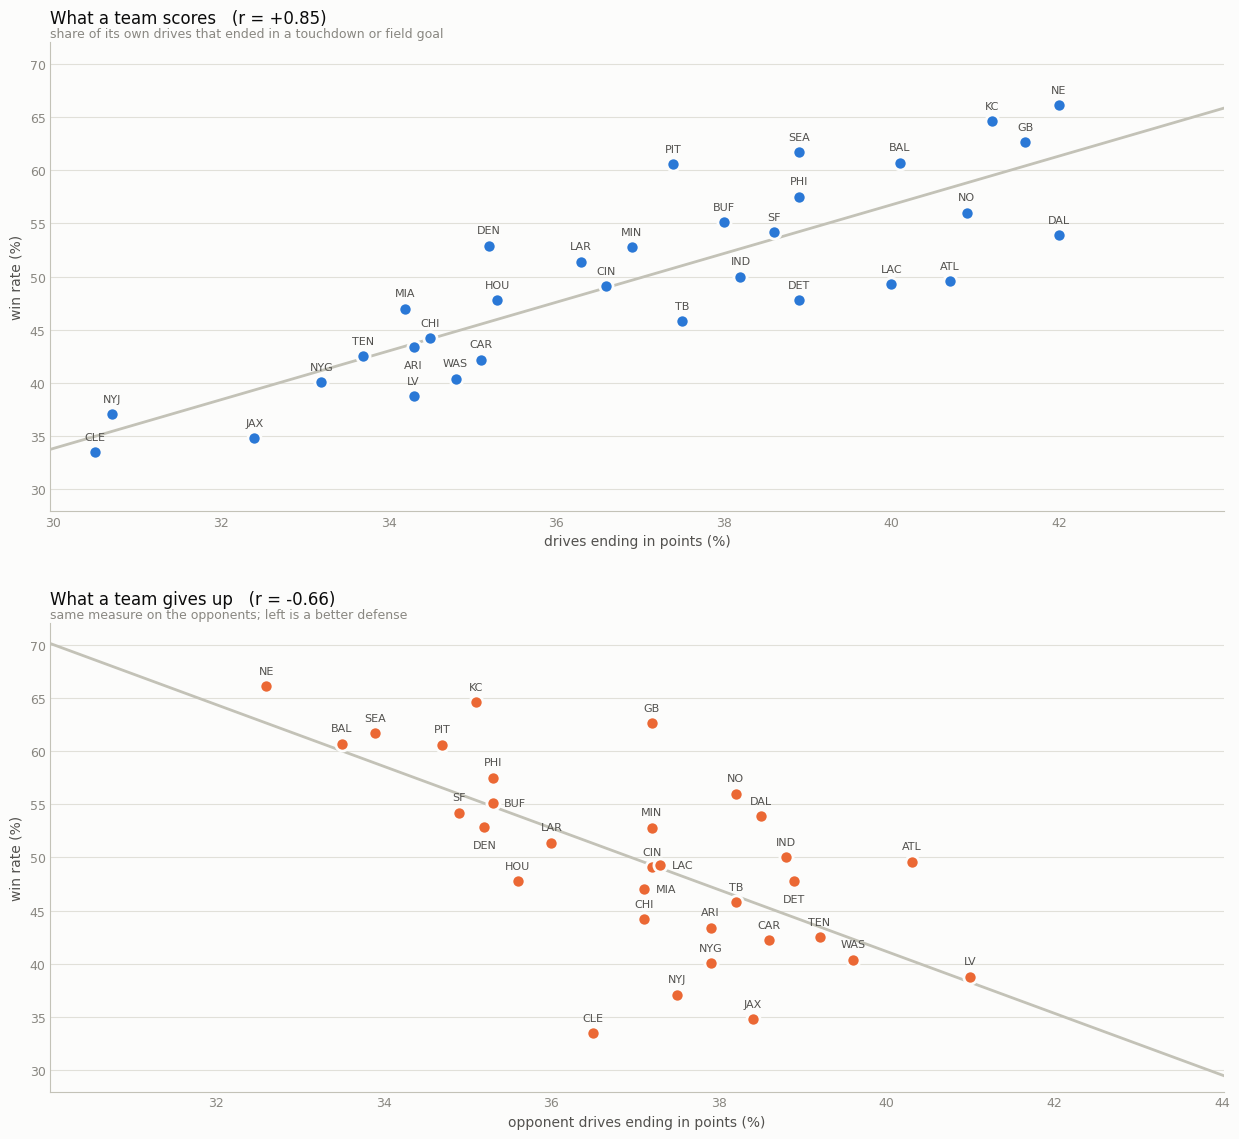

In [14]:
def label_every_team(ax, fig, x, y):
    """Name all 32 dots: try positions around each one until nothing collides.

    Placement is measured in pixels off a drawn figure, so it has to run after
    `tight_layout`. Candidates are ordered close-to-far; anything that ends up
    on one of the outer rings gets a leader line back to its dot, since by then
    the label is too far away to read as belonging to it.
    """
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    frame = ax.get_window_extent()
    pixels = ax.transData.transform(np.column_stack([x.to_numpy(), y.to_numpy()]))

    # The dots themselves are obstacles, so a label never lands on one.
    taken = [(px - 7, py - 7, px + 7, py + 7) for px, py in pixels]
    NEAR = [(0, 11), (0, -13), (16, 0), (-16, 0), (14, 9), (-14, 9), (14, -10), (-14, -10)]
    FAR = [(0, 23), (0, -25), (30, 0), (-30, 0), (26, 17), (-26, 17), (26, -18), (-26, -18)]

    def free(box):
        return all(box[2] < o[0] or box[0] > o[2] or box[3] < o[1] or box[1] > o[3] for o in taken)

    def inside(box):
        return box[0] >= frame.x0 and box[2] <= frame.x1 and box[1] >= frame.y0 and box[3] <= frame.y1

    for team in x.index:
        for i, (dx, dy) in enumerate(NEAR + FAR):
            text = ax.annotate(
                team, xy=(x[team], y[team]), xytext=(dx, dy), textcoords="offset points",
                ha="center", va="center", color=INK_2, fontsize=8, zorder=4,
            )
            bb = text.get_window_extent(renderer)
            box = (bb.x0 - 2, bb.y0 - 1, bb.x1 + 2, bb.y1 + 1)
            if inside(box) and free(box):
                if i >= len(NEAR):
                    ax.annotate(
                        "", xy=(x[team], y[team]), xytext=(dx, dy), textcoords="offset points",
                        arrowprops=dict(arrowstyle="-", color=AXIS, linewidth=0.7,
                                        shrinkA=0, shrinkB=5), zorder=2,
                    )
                taken.append(box)
                break
            text.remove()
        else:  # nothing fit anywhere: keep it above the dot and accept the overlap
            text = ax.annotate(
                team, xy=(x[team], y[team]), xytext=(0, 11), textcoords="offset points",
                ha="center", va="center", color=INK_2, fontsize=8, zorder=4,
            )
            taken.append(tuple(text.get_window_extent(renderer).extents))


def scatter_panel(ax, x, y, color):
    """32 dots and a fitted line. Labels are added later, after tight_layout."""
    xs, ys = x.to_numpy(), y.to_numpy()
    slope, intercept = np.polyfit(xs, ys, 1)

    half = 7.0  # same x half-width on both panels, so the slopes compare
    lo, hi = xs.mean() - half, xs.mean() + half
    line_x = np.array([lo, hi])
    ax.plot(line_x, slope * line_x + intercept, color=AXIS, linewidth=2, zorder=1)
    ax.scatter(xs, ys, s=90, color=color, edgecolor=SURFACE, linewidth=2, zorder=3)

    strip_chrome(ax)
    ax.set_xlim(lo, hi)
    ax.set_ylim(28, 72)
    ax.set_ylabel("win rate (%)", color=INK_2, fontsize=10)


# Stacked rather than side by side: naming all 32 teams needs the full width.
fig, (ax_off, ax_def) = plt.subplots(2, 1, figsize=(12.5, 11.5), facecolor=SURFACE)
ORANGE = "#eb6834"

scatter_panel(ax_off, rates["score%"], rates["win%"], BLUE)
ax_off.set_xlabel("drives ending in points (%)", color=INK_2, fontsize=10)
ax_off.set_title(
    f"What a team scores   (r = {r_off:+.2f})", color=INK, fontsize=12, loc="left", pad=14
)
ax_off.text(
    0, 1.012, "share of its own drives that ended in a touchdown or field goal",
    transform=ax_off.transAxes, color=MUTED, fontsize=9,
)

scatter_panel(ax_def, rates["allowed%"], rates["win%"], ORANGE)
ax_def.set_xlabel("opponent drives ending in points (%)", color=INK_2, fontsize=10)
ax_def.set_title(
    f"What a team gives up   (r = {r_def:+.2f})", color=INK, fontsize=12, loc="left", pad=14
)
ax_def.text(
    0, 1.012, "same measure on the opponents; left is a better defense",
    transform=ax_def.transAxes, color=MUTED, fontsize=9,
)

fig.tight_layout(h_pad=3.0)
label_every_team(ax_off, fig, rates["score%"], rates["win%"])
label_every_team(ax_def, fig, rates["allowed%"], rates["win%"])
plt.show()